# App Insights Unlocked: A Data Analytics Challenge

## Objective
Perform targeted analysis to identify high-performing categories, the impact of app size on user ratings, and the relationship between app price and user reviews.

# EDA-1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('googleplaystore.csv')

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
df.shape

(10841, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [ ]:
df = df.dropna(subset=('Reviews'))

In [ ]:
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.strip()
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [ ]:
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [ ]:
df.duplicated().sum()

np.int64(483)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

In [ ]:
df[df['Last Updated'].isna()].dropna(inplace=True)

/tmp/ipykernel_894/1400771646.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['Last Updated'].isna()].dropna(inplace=True)


In [ ]:
df[df['Reviews'].isna()].dropna(inplace=True)

/tmp/ipykernel_894/3558127688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['Reviews'].isna()].dropna(inplace=True)


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
def convert_size(x):
    if pd.isna(x):
        return None
    elif 'M' in x:
        return float(x.replace('M', ''))
    elif 'k' in x:
        return float(x.replace('k', '')) / 1024
    else:
        return None

df['size_mb'] = df['Size'].apply(convert_size)

In [ ]:
df['size_mb'] = df['size_mb'].fillna(0)

# 1.BASIC

In [ ]:
# 1.Average rating of apps
print(df['Rating'].mean())

4.187876743139902


In [ ]:
# 2.Unique categories of apps
print(df['Category'].unique())

['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION']


In [ ]:
# 3.Distribution of app sizes
bins = [0, 10, 30, 60, 100, df['size_mb'].max() + 1]
labels = ['0-10MB', '10-30MB', '30-60MB', '60-100MB', '100MB+']

df['size_groups'] = pd.cut(df['size_mb'], bins=bins, labels=labels)

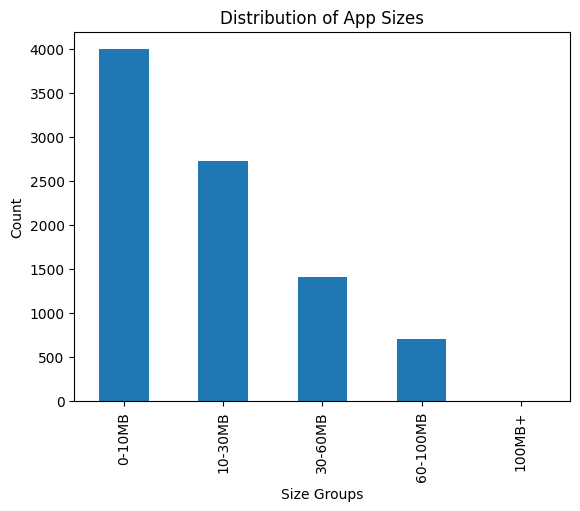

In [ ]:
df['size_groups'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Size Groups')
plt.ylabel('Count')
plt.title('Distribution of App Sizes')
plt.show()

In [ ]:
# 4.Free vs paid apps
print(df['Type'].value_counts())


Type
Free    9591
Paid     765
Name: count, dtype: int64


In [ ]:
# 5.Most common content rating for apps
df['Content Rating'].mode()

,Content Rating
0,Everyone


In [ ]:
# 6.Top 5 most installed apps
df.sort_values(by='Installs', ascending=False).head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,size_mb,size_groups
3035,Google Drive,PRODUCTIVITY,4.4,2731171.0,Varies with device,1000000000,Free,0.0,Everyone,Productivity,2018-08-06,Varies with device,Varies with device,0.0,NaN
755,Google Play Games,ENTERTAINMENT,4.3,7165362.0,Varies with device,1000000000,Free,0.0,Teen,Entertainment,2018-07-16,Varies with device,Varies with device,0.0,NaN
3102,Google Drive,PRODUCTIVITY,4.4,2731211.0,Varies with device,1000000000,Free,0.0,Everyone,Productivity,2018-08-06,Varies with device,Varies with device,0.0,NaN
2246,Facebook,SOCIAL,4.1,78158306.0,Varies with device,1000000000,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device,0.0,NaN
2247,Instagram,SOCIAL,4.5,66577313.0,Varies with device,1000000000,Free,0.0,Teen,Social,2018-07-31,Varies with device,Varies with device,0.0,NaN


In [ ]:
# 7.No of Apps have a rating of 4.0 and above
df[df['Rating'] >= 4.0]['App'].nunique()

6287

In [ ]:
# 8.Average number of reviews for free vs paid apps
df.groupby('Type')['Reviews'].mean()

,Reviews
Type,
Free,437373.593056
Paid,11900.550327


In [ ]:
# 9.Average app size for each category
df.groupby('Category')['size_mb'].mean().sort_values(ascending=False)

,size_mb
Category,
GAME,39.363797
FAMILY,25.960860
SPORTS,20.391948
PARENTING,20.261667
TRAVEL_AND_LOCAL,18.516274
MEDICAL,18.052849
AUTO_AND_VEHICLES,17.679536
FOOD_AND_DRINK,17.431452
HEALTH_AND_FITNESS,16.974760


In [ ]:
# 10.No of Apps were last updated in 2018
df[df['Last Updated'].dt.year == 2018]['App'].nunique()

6287

# 2.MEDIUM

In [ ]:
df_filtered = df[~df['Installs'].isna()].reset_index()
df_filtered = df[~df['Rating'].isna()].reset_index()

In [ ]:
# 1.Correlation between the number of installs and the app rating
p = df['Rating'].corr(df['Installs'])
n = np.corrcoef(df_filtered['Rating'], df_filtered['Installs'])[0,1]
print(f'using pandas: {p}')
print(f'using numpy: {n}')

using pandas: 0.05088596249846877
using numpy: 0.05088596249846877


In [ ]:
# 2.Highest average rating Categories
df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

,Rating
Category,
EVENTS,4.435556
EDUCATION,4.375969
ART_AND_DESIGN,4.358065
BOOKS_AND_REFERENCE,4.347458
PERSONALIZATION,4.333871
PARENTING,4.300000
GAME,4.281285
BEAUTY,4.278571
HEALTH_AND_FITNESS,4.261450


In [ ]:
# 3.Price of an app affect its average rating
df[(df['Type']=='Paid')&(~df['Rating'].isna())].groupby('Price')['Rating'].mean().reset_index().sort_values(by='Price',ascending=False)

,Price,Rating
71,400.00,3.600000
70,399.99,4.009091
69,389.99,3.600000
68,379.99,2.900000
67,299.99,3.800000
...,...,...
4,1.49,4.196774
3,1.29,4.100000
2,1.20,4.200000
1,1.00,4.450000


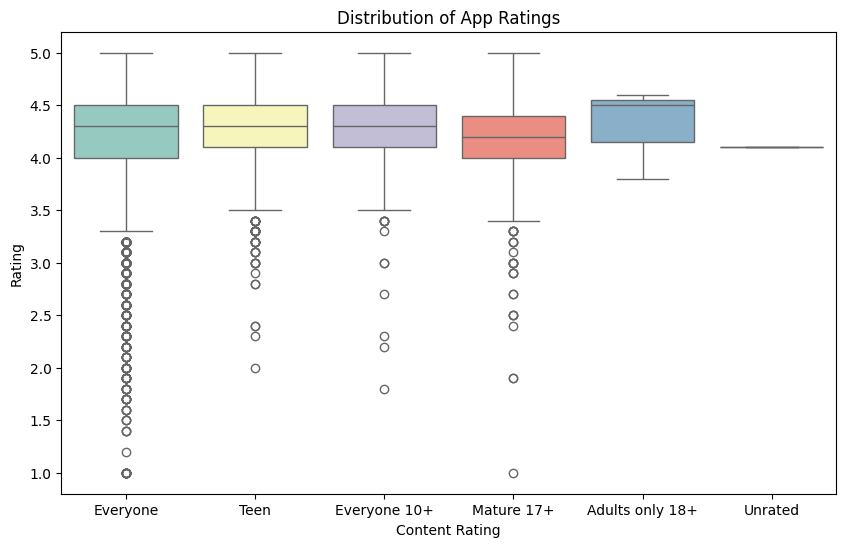

In [ ]:
# 4.Distribution of app ratings across different content ratings
plt.figure(figsize=(10, 6))
sns.boxplot(x='Content Rating', y='Rating',hue='Content Rating', data=df, palette='Set3')
plt.xlabel('Content Rating')
plt.ylabel('Rating')
plt.title('Distribution of App Ratings')
plt.show()

In [ ]:
# 5.Genres with most apps with over 1 million installs
df[df['Installs'] > 1000000].groupby('Genres').agg(App_count = ('App', 'nunique'),
                                                   installs = ('Installs', 'sum')).sort_values(by='App_count', ascending=False)

,App_count,installs
Genres,,
Tools,173,11315000000
Action,128,8265000000
Photography,124,9660000000
Communication,99,24100000000
Productivity,91,12395000000
...,...,...
Parenting,1,10000000
Role Playing;Brain Games,1,10000000
Sports;Action & Adventure,1,10000000


In [ ]:
# 6.Average time between updates
df.groupby('App')['Last Updated'].diff().mean()

Timedelta('-1 days +19:15:18.051575932')

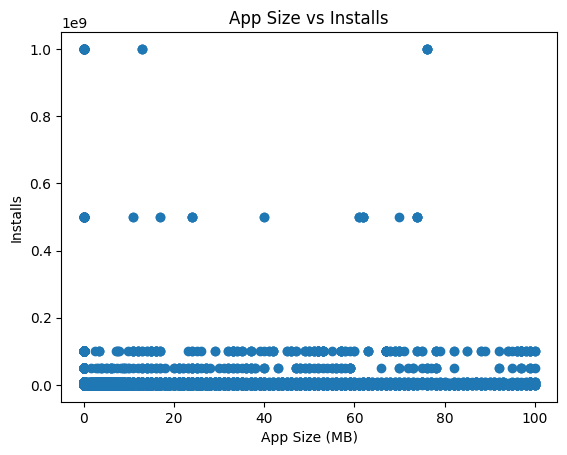

In [ ]:
# 7.App size vs installs
plt.scatter(df_filtered['size_mb'], df_filtered['Installs'])
plt.xlabel('App Size (MB)')
plt.ylabel('Installs')
plt.title('App Size vs Installs')
plt.show()

In [ ]:
# 8.Highest number of reviews and Ratings
filtered = df[(df['Reviews'] > 0) & (~df['Rating'].isna())]

stats = filtered.groupby('App').agg(
    Reviews=('Reviews', 'sum'),
    Rating=('Rating', 'mean')
).reset_index().sort_values(by='Reviews', ascending=False)

stats[['App','Reviews','Rating']].head()

,App,Reviews,Rating
4422,Instagram,199664676.0,4.5
3432,Facebook,156286514.0,4.1
6807,Subway Surfers,138606606.0,4.5
7665,WhatsApp Messenger,138228988.0,4.4
2073,Clash of Clans,134667058.0,4.6


In [ ]:
# 9.Content rating distribution differ between free and paid apps
pd.crosstab(df['Content Rating'], df['Type'])

Type,Free,Paid
Content Rating,,
Adults only 18+,3,0
Everyone,7720,662
Everyone 10+,344,32
Mature 17+,428,19
Teen,1094,52
Unrated,2,0


In [ ]:
# 10.Top 5 categories with the most installs
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(5)

,Installs
Category,
GAME,31544024415
COMMUNICATION,24152276251
SOCIAL,12513867902
PRODUCTIVITY,12463091369
TOOLS,11452771915


# 3.ADVANCED

In [ ]:
# 1.Top 10 Apps by Rating and Comparison of Reviews & Installs
df[df['Rating']>0].groupby('App').agg({'Rating':'mean',
                                       'Reviews': 'sum',
                                       'Installs' :'sum'}).sort_values(by='Rating', ascending=False).head(10)

,Rating,Reviews,Installs
App,,,
CN Resident,5.0,1.0,100
CZ Kompas,5.0,2.0,10
211:CK,5.0,8.0,10
Sir C J New Primary School,5.0,3.0,100
Accounting Quiz (AQ) Malaysia,5.0,25.0,1000
DV ASSIST,5.0,1.0,100
DV Youth,5.0,5.0,100
DN Employee,5.0,1.0,10
DT CLOTHINGS,5.0,1.0,10


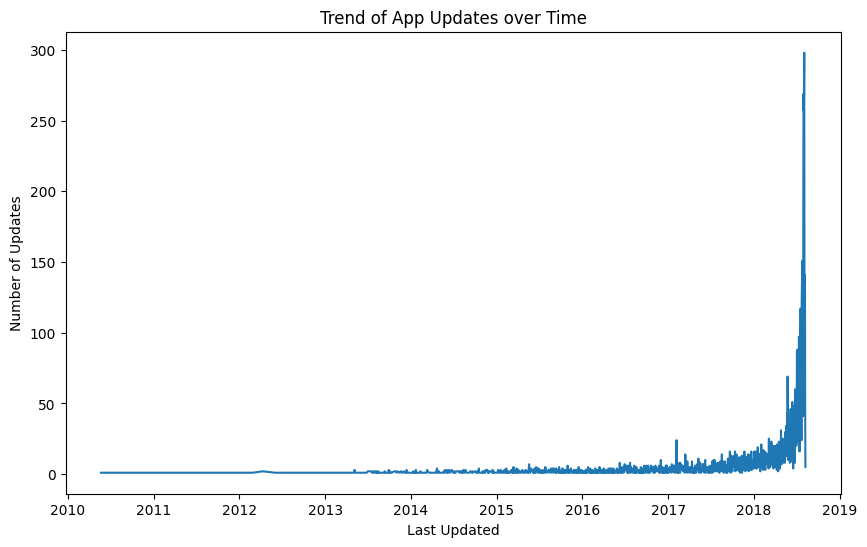

In [ ]:
# 2.Trend of app updates over time
plt.figure(figsize=(10, 6))
plt.plot(df.groupby('Last Updated').size().index, df.groupby('Last Updated').size().values)
plt.xlabel('Last Updated')
plt.ylabel('Number of Updates')
plt.title('Trend of App Updates over Time')
plt.show()

In [ ]:
# 3.Average rating of apps change with the number of installs
max_installs = df['Installs'].max()
bins = [0, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000, max_installs+1]
labels = ['0-1k', '1k-10k', '10k-100k', '100k-1M', '1M-10M', '10M-100M', '100M-1B', '>1B']
df['Installs_Bin'] = pd.cut(df['Installs'], bins=bins, labels=labels, include_lowest=True)
df.groupby('Installs_Bin',observed=False)['Rating'].mean().sort_index()

,Rating
Installs_Bin,
0-1k,4.198504
1k-10k,4.031095
10k-100k,4.094593
100k-1M,4.207043
1M-10M,4.285675
10M-100M,4.382995
100M-1B,4.309091
>1B,NaN


In [ ]:
# 5.Relationship between app genre and user ratings
df_filtered.groupby('Genres')['Rating'].mean().sort_values(ascending=False).round(1)

,Rating
Genres,
Board;Pretend Play,4.8
Comics;Creativity,4.8
Health & Fitness;Education,4.7
Puzzle;Education,4.6
Strategy;Action & Adventure,4.6
...,...
Art & Design;Pretend Play,3.9
Health & Fitness;Action & Adventure,3.9
Educational,3.9
